In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("quant101/cc-fraud-dataset")

print("Dataset path:", path)

# See what files were downloaded
print(os.listdir(path))

# Load the CSV
data = pd.read_csv(os.path.join(path, "creditcard.csv"))

data.head()


Using Colab cache for faster access to the 'cc-fraud-dataset' dataset.
Dataset path: /kaggle/input/cc-fraud-dataset
['.nfs00000000c17462a600000016', 'creditcard.csv']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
print("Missing values:", data.isnull().sum().max())
print("Duplicates:", data.duplicated().sum())
data = data.drop_duplicates()

Missing values: 0
Duplicates: 1081


In [8]:
print("Class Distribution:")
print(data['Class'].value_counts())
print("\nPercentage:")
print(data['Class'].value_counts(normalize=True) * 100)

Class Distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [9]:
X = data.drop(columns=['Class'])
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

Class distribution after SMOTE:
Class
0    212439
1    212439
Name: count, dtype: int64


In [11]:
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history1 = model1.fit(X_train_res, y_train_res, validation_split=0.2, epochs=20, batch_size=512)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9679 - loss: 0.0839 - val_accuracy: 0.9952 - val_loss: 0.0270
Epoch 2/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9973 - loss: 0.0136 - val_accuracy: 0.9996 - val_loss: 0.0082
Epoch 3/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9987 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 4/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9992 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 5/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 6/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9996 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 7/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 8/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9997 - loss: 0.0016 - val_accuracy: 1.

In [12]:
model2 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train_res.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history2 = model2.fit(X_train_res, y_train_res, validation_split=0.2, epochs=20, batch_size=512)

Epoch 1/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9142 - loss: 0.2540 - val_accuracy: 0.8930 - val_loss: 0.1850
Epoch 2/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9501 - loss: 0.1304 - val_accuracy: 0.9056 - val_loss: 0.1747
Epoch 3/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9541 - loss: 0.1154 - val_accuracy: 0.9146 - val_loss: 0.1638
Epoch 4/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9566 - loss: 0.1075 - val_accuracy: 0.9203 - val_loss: 0.1537
Epoch 5/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9586 - loss: 0.1016 - val_accuracy: 0.9236 - val_loss: 0.1484
Epoch 6/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9605 - loss: 0.0967 - val_accuracy: 0.9265 - val_loss: 0.1420
Epoch 7/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9623 - loss: 0.0924 - val_accuracy: 0.9290 - val_loss: 0.1366
Epoch 8/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9639 - loss: 0.0886 - val_accuracy: 0.

In [13]:
model3 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
history3 = model3.fit(X_train_res, y_train_res, validation_split=0.2, epochs=20, batch_size=512)

Epoch 1/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9809 - loss: 0.0621 - val_accuracy: 0.9988 - val_loss: 0.0182
Epoch 2/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9984 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 3/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9991 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 4/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9993 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 5/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9995 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 6.4567e-04
Epoch 6/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 7.2472e-04
Epoch 7/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9996 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 5.6035e-04
Epoch 8/20
664/664 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9996 - loss: 0.0017 - val_

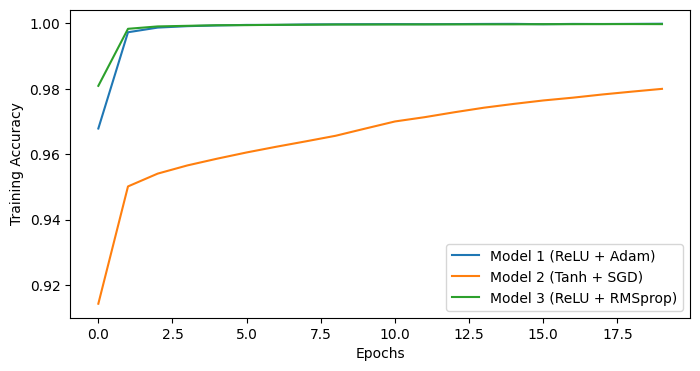

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(history1.history['accuracy'], label='Model 1 (ReLU + Adam)')
plt.plot(history2.history['accuracy'], label='Model 2 (Tanh + SGD)')
plt.plot(history3.history['accuracy'], label='Model 3 (ReLU + RMSprop)')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.legend()
plt.show()

In [15]:
pred1_prob = model1.predict(X_test, verbose=0)
pred2_prob = model2.predict(X_test, verbose=0)
pred3_prob = model3.predict(X_test, verbose=0)

pred1 = (pred1_prob >= 0.5).astype(int).flatten()
pred2 = (pred2_prob >= 0.5).astype(int).flatten()
pred3 = (pred3_prob >= 0.5).astype(int).flatten()

results = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'Activation': ['ReLU', 'Tanh', 'ReLU'],
    'Optimizer': ['Adam', 'SGD', 'RMSprop'],
    'Epochs': [20, 20, 20],
    'Accuracy': [accuracy_score(y_test, pred1), accuracy_score(y_test, pred2), accuracy_score(y_test, pred3)],
    'Precision': [precision_score(y_test, pred1), precision_score(y_test, pred2), precision_score(y_test, pred3)],
    'Recall': [recall_score(y_test, pred1), recall_score(y_test, pred2), recall_score(y_test, pred3)],
    'F1': [f1_score(y_test, pred1), f1_score(y_test, pred2), f1_score(y_test, pred3)]
})

results

,Model,Activation,Optimizer,Epochs,Accuracy,Precision,Recall,F1
0,Model 1,ReLU,Adam,20,0.998985,0.666667,0.779661,0.718750
1,Model 2,Tanh,SGD,20,0.987523,0.105858,0.872881,0.188818
2,Model 3,ReLU,RMSprop,20,0.999041,0.686567,0.779661,0.730159


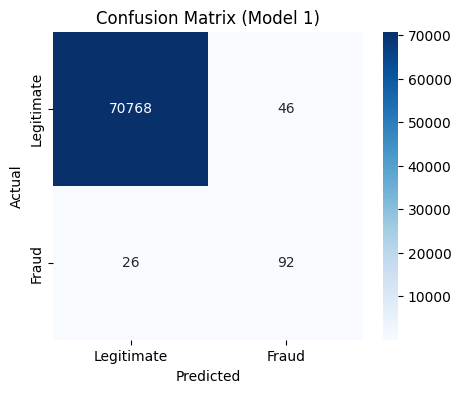

In [16]:
cm = confusion_matrix(y_test, pred1)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Model 1)')
plt.show()

In [17]:
sdata = pd.DataFrame({
    'Actual Class': y_test.values[:10],
    'Predicted Class': pred1[:10]
})

sdata['Actual Label'] = sdata['Actual Class'].map({0: 'Legitimate', 1: 'Fraud'})
sdata['Predicted Label'] = sdata['Predicted Class'].map({0: 'Legitimate', 1: 'Fraud'})
sdata

,Actual Class,Predicted Class,Actual Label,Predicted Label
0,0,0,Legitimate,Legitimate
1,0,0,Legitimate,Legitimate
2,0,0,Legitimate,Legitimate
3,0,0,Legitimate,Legitimate
4,0,0,Legitimate,Legitimate
5,0,0,Legitimate,Legitimate
6,0,0,Legitimate,Legitimate
7,0,0,Legitimate,Legitimate
8,0,0,Legitimate,Legitimate
9,0,0,Legitimate,Legitimate
